<a href="https://colab.research.google.com/github/sanjanabalan84-glitch/ML-AI-PROJECT/blob/main/DAY_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#UNSUPERVISED LEARNING AND KMEANS CLUSTER

In [ ]:
# unsupervised learning means unlabeled
# we don't know where to fill
# clustering identify by the similarity
# two information given in same meaning we dimensionality reduction (we can reduce)
# association rule is use when one is related to other
# customer segmentation,image and video,fraud detection,recommendation systems


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
df.shape

(200, 5)

In [ ]:
df.size

1000

In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


<Axes: >

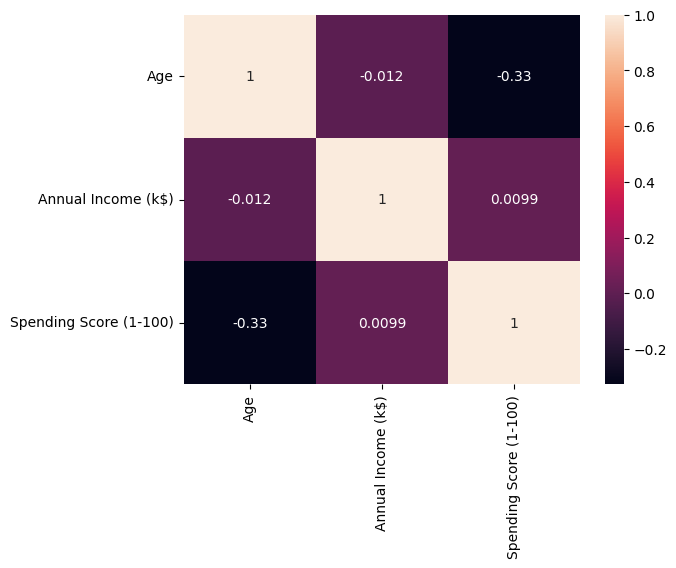

In [ ]:
data=df.drop(columns=['CustomerID','Gender'])
sns.heatmap(data.corr(),annot=True)

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

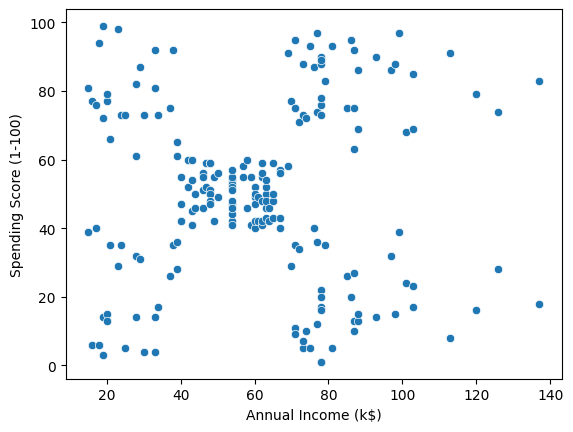

In [ ]:
sns.scatterplot(data=df,x='Annual Income (k$)',y='Spending Score (1-100)')

In [ ]:
# applying scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(data.drop(columns=['Age']))
X_scaled


array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

In [ ]:
# kmean
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
wcss=[]
sil_scores=[]
for k in range(2,11):  #2-10 cluster
  kmeans=KMeans(n_clusters=k,random_state=42,init='k-means++',max_iter=300,n_init=10)
  kmeans.fit_predict(X_scaled)
  labels=kmeans.labels_
  wcss.append(kmeans.inertia_)
  sil_h=silhouette_score(X_scaled,labels)
  sil_scores.append(sil_h)

In [ ]:
for i,k in enumerate(range(2,11)):
  print(f"for k={k},wcss={wcss[i]:.2f} and sil_score={sil_scores[i]:.2f} ")

for k=2,wcss=269.69 and sil_score=0.32 
for k=3,wcss=157.70 and sil_score=0.47 
for k=4,wcss=108.92 and sil_score=0.49 
for k=5,wcss=65.57 and sil_score=0.55 
for k=6,wcss=55.06 and sil_score=0.54 
for k=7,wcss=44.86 and sil_score=0.53 
for k=8,wcss=37.23 and sil_score=0.46 
for k=9,wcss=32.39 and sil_score=0.46 
for k=10,wcss=29.98 and sil_score=0.44 


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

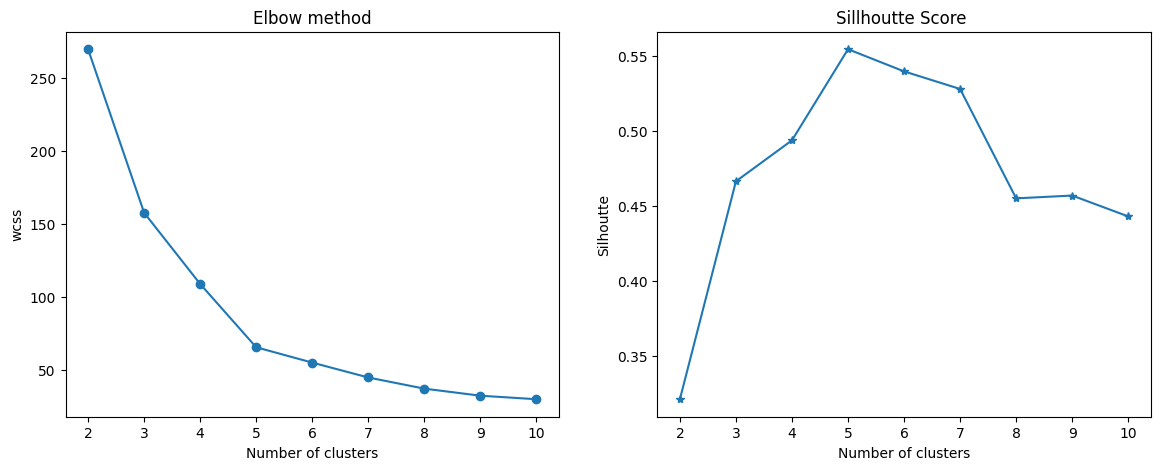

In [ ]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(range(2,11),wcss,marker='o')
plt.title("Elbow method")
plt.xlabel("Number of clusters")
plt.ylabel("wcss")

plt.subplot(1,2,2)
plt.plot(range(2,11),sil_scores,marker='*')
plt.title("Sillhoutte Score ")
plt.xlabel("Number of clusters")
plt.ylabel("Silhoutte")
plt

In [ ]:
kmeans=KMeans(n_clusters=5,random_state=42,init='k-means++',max_iter=300,n_init=10)
kmeans.fit(X_scaled)
cluster_labels=kmeans.predict(X_scaled)
cluster_labels

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [ ]:
df['kmean_cluster']=cluster_labels
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),kmean_cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [ ]:
df['kmean_cluster'].value_counts()

,count
kmean_cluster,
0,81
1,39
3,35
4,23
2,22


<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

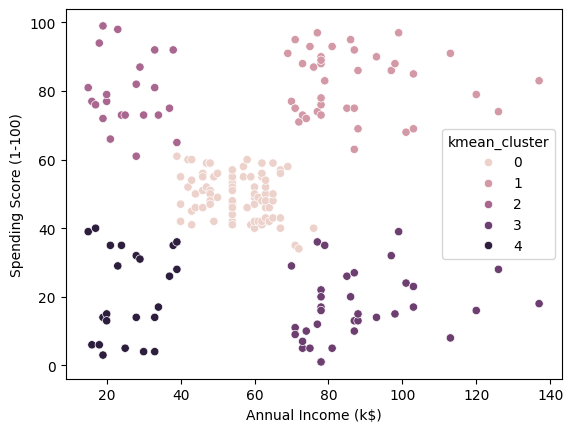

In [ ]:
sns.scatterplot(data=df,x='Annual Income (k$)',y='Spending Score (1-100)',hue='kmean_cluster')

In [ ]:
new_customer=np.array([[45,60]])
scaled=scaler.transform(new_customer)
cluster=kmeans.predict(scaled)
cluster

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0], dtype=int32)

In [ ]:
#Agglomeraitive hierarchical clustering

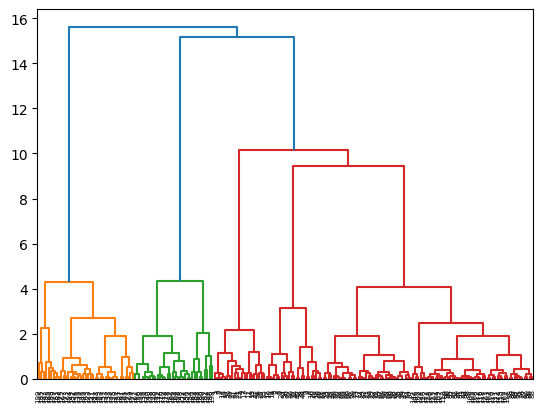

In [ ]:
from scipy.cluster.hierarchy import dendrogram,linkage
mergings=linkage(X_scaled,'ward')
dendrogram(mergings);

In [ ]:
from scipy.cluster.hierarchy import fcluster
cluster_labels=fcluster(mergings,t=5,criterion='maxclust')
cluster_labels

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 5,
       4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 1, 5, 1, 5, 1, 2, 1, 2, 1,
       5, 1, 2, 1, 2, 1, 2, 1, 2, 1, 5, 1, 2, 1, 5, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 5, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1], dtype=int32)

In [ ]:
from sklearn.cluster import AgglomerativeClustering
agg_hc=AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='ward')
agg_cluster=agg_hc.fit_predict(X_scaled)
agg_cluster

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 2,
       4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 0, 1, 0, 1,
       2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1])

In [ ]:
df['agg_cluster']=agg_cluster
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),kmean_cluster,agg_cluster
0,1,Male,19,15,39,4,4
1,2,Male,21,15,81,2,3
2,3,Female,20,16,6,4,4
3,4,Female,23,16,77,2,3
4,5,Female,31,17,40,4,4


In [ ]:
df.kmean_cluster.value_counts()

,count
kmean_cluster,
0,81
1,39
3,35
4,23
2,22


In [ ]:
df['agg_cluster'].value_counts()

,count
agg_cluster,
2,85
1,39
0,32
4,23
3,21


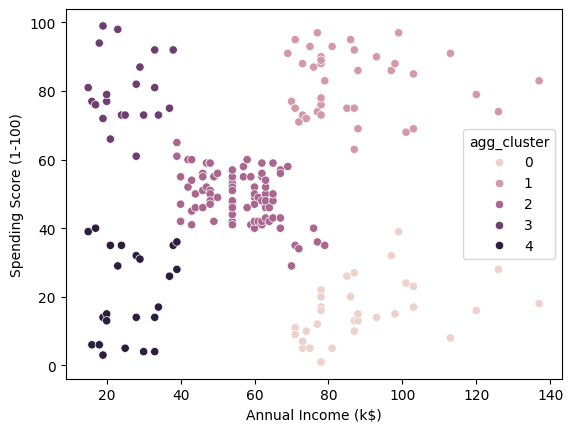

In [ ]:
sns.scatterplot(data=df,x='Annual Income (k$)',y='Spending Score (1-100)',hue='agg_cluster');

In [ ]:
sil_scores={}
for i in range(2,11):
  agg_hc=AgglomerativeClustering(n_clusters=i,metric='euclidean',linkage='ward')
  sill_h=silhouette_score(X_scaled,agg_hc.fit_predict(X_scaled))
  sil_scores[i]=sill_h
sil_scores



{2: np.float64(0.3842337621772661),
 3: np.float64(0.4610481446570447),
 4: np.float64(0.4925507715349343),
 5: np.float64(0.5538089226688662),
 6: np.float64(0.5386761871036926),
 7: np.float64(0.5197949293475768),
 8: np.float64(0.4308617778221774),
 9: np.float64(0.43768997758154127),
 10: np.float64(0.4339007174968657)}

In [ ]:
from sklearn.cluster import DBSCAN
db_scan=DBSCAN(eps=0.3,min_samples=5)
db_cluster=db_scan.fit_predict(X_scaled)
db_cluster

array([ 2,  0,  1,  0,  2,  0,  1, -1,  1,  0, -1, -1, -1,  0,  1,  0,  2,
        0,  2, -1,  2,  0,  1,  0, -1, -1,  2, -1,  2, -1, -1,  0, -1, -1,
       -1, -1, -1,  0, -1,  0,  3, -1,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        3,  3,  3,  3,  4,  3,  4,  3,  4,  5,  4,  5,  4,  3,  4,  5,  4,
        5,  4,  5,  4,  5,  4,  3,  4,  5,  4,  3,  4,  5,  4,  5,  4,  5,
        4,  5,  4,  5,  4,  5,  4,  3,  4,  5,  4,  6,  4,  6,  4,  6, -1,
        6,  4,  6,  4,  6,  4,  6,  4,  6,  4, -1,  4,  6,  4, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [ ]:
df['db_cluster']=db_cluster
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),kmean_cluster,agg_cluster,db_cluster
0,1,Male,19,15,39,4,4,2
1,2,Male,21,15,81,2,3,0
2,3,Female,20,16,6,4,4,1
3,4,Female,23,16,77,2,3,0
4,5,Female,31,17,40,4,4,2


In [ ]:
df.kmean_cluster.value_counts()

,count
kmean_cluster,
0,81
1,39
3,35
4,23
2,22


In [ ]:
df['db_cluster'].value_counts()

,count
db_cluster,
3,88
-1,35
4,30
5,14
0,12
6,9
2,7
1,5


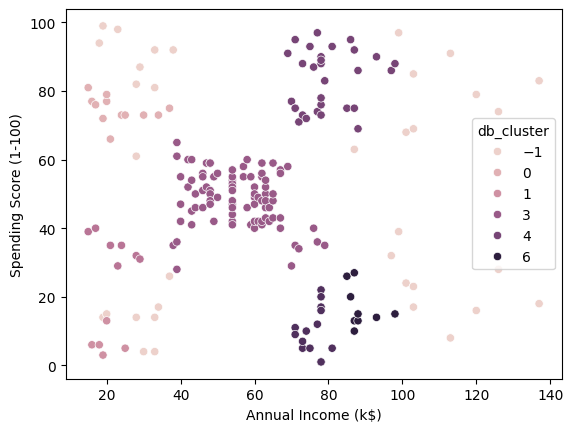

In [ ]:
sns.scatterplot(data=df,x='Annual Income (k$)',y='Spending Score (1-100)',hue='db_cluster');

In [ ]:
sil_scores={}
for i in range(2,11):
  db_hc=DBSCAN(metric='euclidean')
  db_cluster=db_hc.fit_predict(X_scaled,db_hc.fit_predict(X_scaled))
  sil_score=silhouette_score(X_scaled,db_cluster)
  sil_scores[i]=sil_score
sil_scores


{2: np.float64(0.35044619989666004),
 3: np.float64(0.35044619989666004),
 4: np.float64(0.35044619989666004),
 5: np.float64(0.35044619989666004),
 6: np.float64(0.35044619989666004),
 7: np.float64(0.35044619989666004),
 8: np.float64(0.35044619989666004),
 9: np.float64(0.35044619989666004),
 10: np.float64(0.35044619989666004)}

In [ ]:
df=pd.read_csv("/content/fish (1).csv") #unlabeled
df

,Bream,242.0,23.2,25.4,30.0,38.4,13.4
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2
...,...,...,...,...,...,...,...
79,Pike,950.0,48.3,51.7,55.1,16.2,11.2
80,Pike,1250.0,52.0,56.0,59.7,17.9,11.7
81,Pike,1600.0,56.0,60.0,64.0,15.0,9.6
82,Pike,1550.0,56.0,60.0,64.0,15.0,9.6


In [ ]:
df.columns=['species','weight','length 1','length 2','length 3','heigth','width']
df.columns

Index(['species', 'weight', 'length 1', 'length 2', 'length 3', 'heigth',
       'width'],
      dtype='object')

In [ ]:
df.head()

,species,weight,length 1,length 2,length 3,heigth,width
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   species   84 non-null     object 
 1   weight    84 non-null     float64
 2   length 1  84 non-null     float64
 3   length 2  84 non-null     float64
 4   length 3  84 non-null     float64
 5   heigth    84 non-null     float64
 6   width     84 non-null     float64
dtypes: float64(6), object(1)
memory usage: 4.7+ KB


In [ ]:
df.shape

(84, 7)

In [ ]:
df.size

588

In [ ]:
df.describe()

,weight,length 1,length 2,length 3,heigth,width
count,84.000000,84.000000,84.000000,84.000000,84.000000,84.000000
mean,434.017857,27.388095,29.607143,33.157143,27.953571,12.859524
std,382.648669,11.348058,12.249630,13.272086,10.351142,2.129377
min,0.000000,9.300000,9.800000,10.800000,14.500000,8.700000
25%,120.000000,19.325000,20.950000,23.550000,16.875000,10.875000
50%,390.000000,28.450000,30.850000,35.050000,26.900000,13.700000
75%,657.500000,32.725000,36.000000,40.675000,39.225000,14.700000
max,1650.000000,59.000000,63.400000,68.000000,44.500000,16.100000


In [ ]:
df.head()

,species,weight,length 1,length 2,length 3,heigth,width
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2


In [ ]:
data=df.drop(columns=['species'])
data


,weight,length 1,length 2,length 3,heigth,width
0,290.0,24.0,26.3,31.2,40.0,13.8
1,340.0,23.9,26.5,31.1,39.8,15.1
2,363.0,26.3,29.0,33.5,38.0,13.3
3,430.0,26.5,29.0,34.0,36.6,15.1
4,450.0,26.8,29.7,34.7,39.2,14.2
...,...,...,...,...,...,...
79,950.0,48.3,51.7,55.1,16.2,11.2
80,1250.0,52.0,56.0,59.7,17.9,11.7
81,1600.0,56.0,60.0,64.0,15.0,9.6
82,1550.0,56.0,60.0,64.0,15.0,9.6


<Axes: >

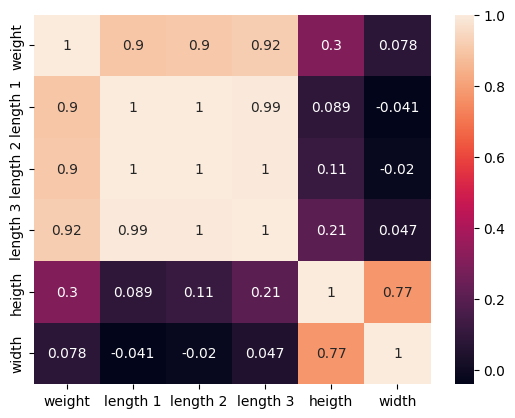

In [ ]:

sns.heatmap(data.corr(),annot=True)

<Axes: xlabel='weight', ylabel='length 1'>

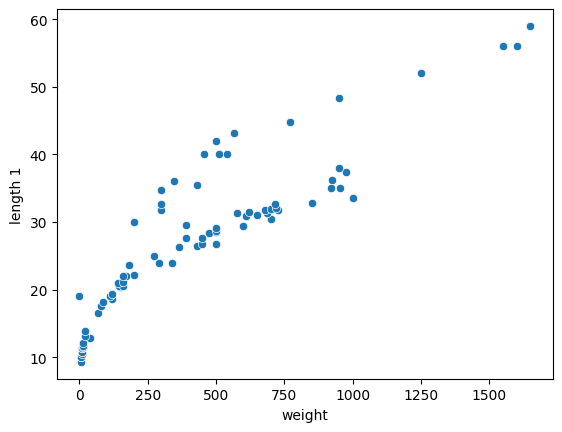

In [ ]:
sns.scatterplot(data=df,x='weight',y='length 1')

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(data)
X_scaled


array([[-0.37863149, -0.30035487, -0.2716005 , -0.14834877,  1.1707675 ,
         0.44432002],
       [-0.24717853, -0.30921988, -0.25517542, -0.15592863,  1.15132991,
         1.05849403],
       [-0.18671016, -0.09645972, -0.04986186,  0.02598811,  0.97639163,
         0.20809925],
       [-0.01056318, -0.0787297 , -0.04986186,  0.06388743,  0.84032853,
         1.05849403],
       [ 0.042018  , -0.05213468,  0.00762593,  0.11694647,  1.09301715,
         0.63329664],
       [ 0.17347097, -0.05213468,  0.00762593,  0.10178675,  1.27767423,
         1.15298234],
       [-0.11572556,  0.01878537,  0.03226356,  0.13968607,  0.80145335,
         0.25534341],
       [ 0.042018  ,  0.01878537,  0.03226356,  0.14726593,  1.16104871,
         0.44432002],
       [ 0.17347097,  0.09857043,  0.08975135,  0.23064443,  1.10273595,
         0.39707587],
       [ 0.10774449,  0.08970542,  0.11438898,  0.23064443,  1.11245474,
         0.58605249],
       [ 0.17347097,  0.11630044,  0.11438898,  0.

In [ ]:
data

,weight,length 1,length 2,length 3,heigth,width
0,290.0,24.0,26.3,31.2,40.0,13.8
1,340.0,23.9,26.5,31.1,39.8,15.1
2,363.0,26.3,29.0,33.5,38.0,13.3
3,430.0,26.5,29.0,34.0,36.6,15.1
4,450.0,26.8,29.7,34.7,39.2,14.2
...,...,...,...,...,...,...
79,950.0,48.3,51.7,55.1,16.2,11.2
80,1250.0,52.0,56.0,59.7,17.9,11.7
81,1600.0,56.0,60.0,64.0,15.0,9.6
82,1550.0,56.0,60.0,64.0,15.0,9.6


In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
wcss=[]
sil_scores=[]
for k in range(2,11):  #2-10 cluster
  kmeans=KMeans(n_clusters=k,random_state=42,init='k-means++',max_iter=300,n_init=10)
  kmeans.fit_predict(X_scaled)
  labels=kmeans.labels_
  wcss.append(kmeans.inertia_)
  sil_h=silhouette_score(X_scaled,labels)
  sil_scores.append(sil_h)

In [ ]:
for i,k in enumerate(range(2,11)):
  print(f"for k={k},wcss={wcss[i]:.2f} and sil_score={sil_scores[i]:.2f} ")

for k=2,wcss=280.89 and sil_score=0.42 
for k=3,wcss=152.52 and sil_score=0.52 
for k=4,wcss=95.64 and sil_score=0.57 
for k=5,wcss=50.03 and sil_score=0.61 
for k=6,wcss=37.64 and sil_score=0.53 
for k=7,wcss=31.31 and sil_score=0.51 
for k=8,wcss=26.62 and sil_score=0.50 
for k=9,wcss=22.88 and sil_score=0.45 
for k=10,wcss=19.87 and sil_score=0.45 


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

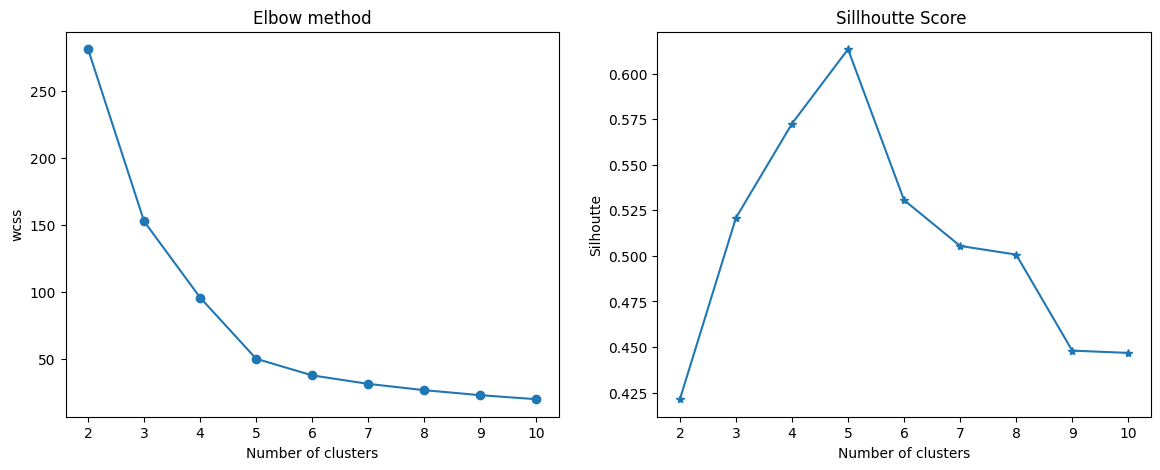

In [ ]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(range(2,11),wcss,marker='o')
plt.title("Elbow method")
plt.xlabel("Number of clusters")
plt.ylabel("wcss")

plt.subplot(1,2,2)
plt.plot(range(2,11),sil_scores,marker='*')
plt.title("Sillhoutte Score ")
plt.xlabel("Number of clusters")
plt.ylabel("Silhoutte")
plt

In [ ]:
kmeans=KMeans(n_clusters=5,random_state=42,init='k-means++',max_iter=300,n_init=10)
kmeans.fit(X_scaled)
cluster_labels=kmeans.predict(X_scaled)
cluster_labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1,
       3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4], dtype=int32)

In [ ]:
data['kmean_cluster']=cluster_labels
data.head()

,weight,length 1,length 2,length 3,heigth,width,kmean_cluster
0,290.0,24.0,26.3,31.2,40.0,13.8,0
1,340.0,23.9,26.5,31.1,39.8,15.1,0
2,363.0,26.3,29.0,33.5,38.0,13.3,0
3,430.0,26.5,29.0,34.0,36.6,15.1,0
4,450.0,26.8,29.7,34.7,39.2,14.2,0


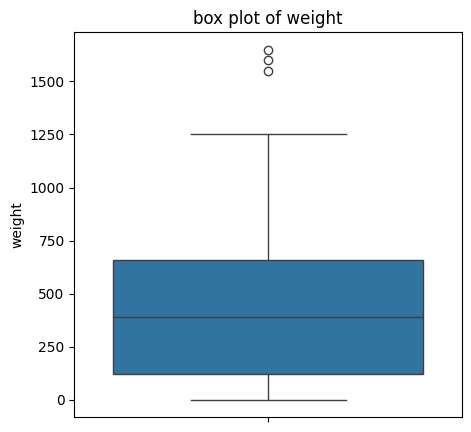

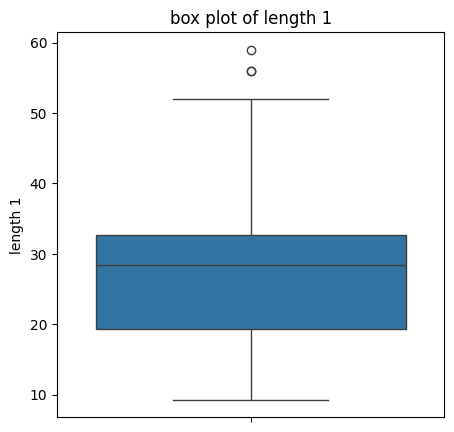

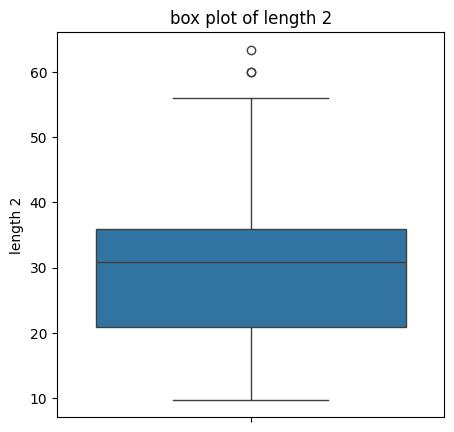

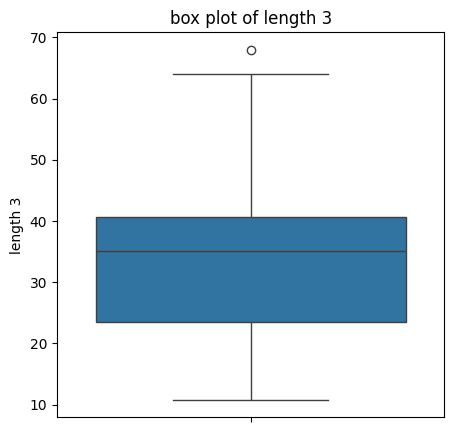

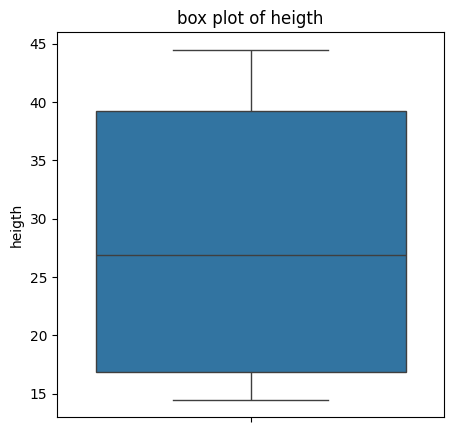

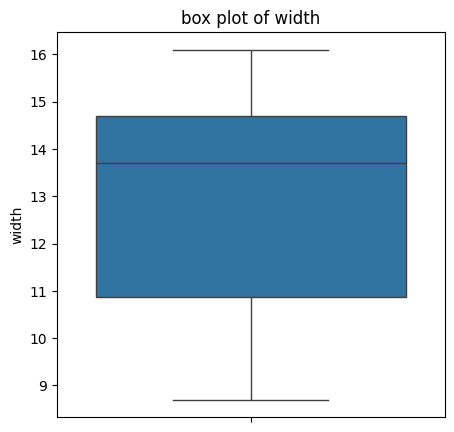

In [ ]:
numerical_cols=df.select_dtypes(include=np.number).columns
for col in numerical_cols:
  plt.figure(figsize=(5,5))
  sns.boxplot(y=df[col])
  plt.title(f'box plot of {col}')
  plt.show()

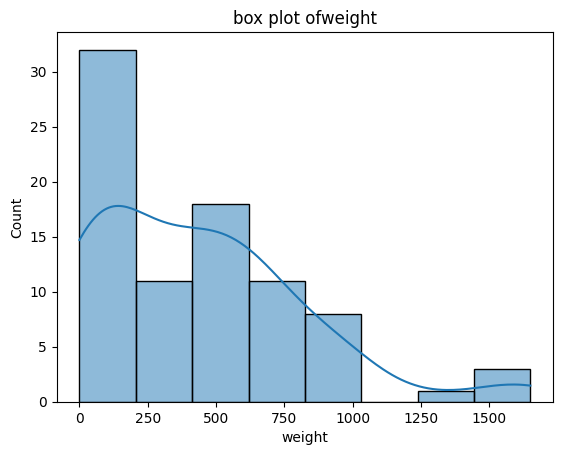

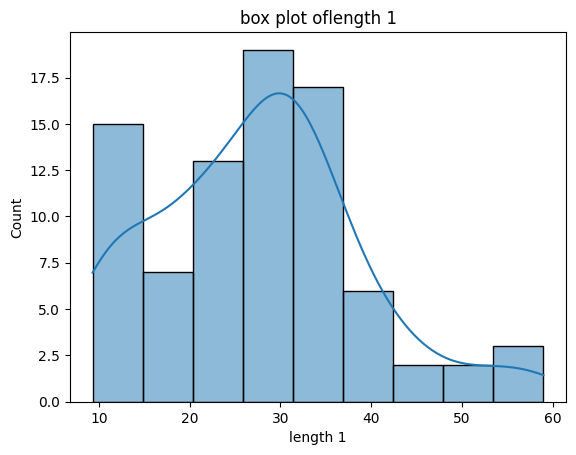

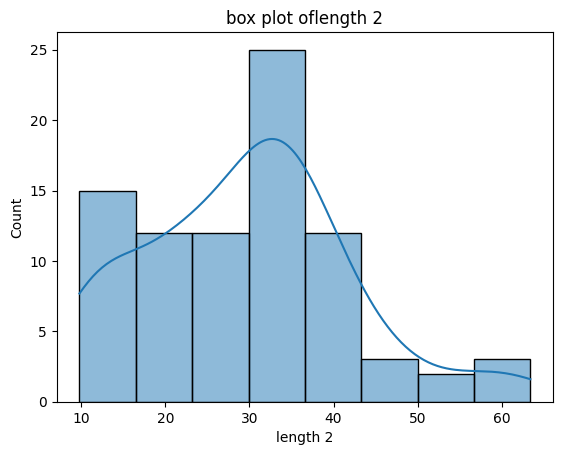

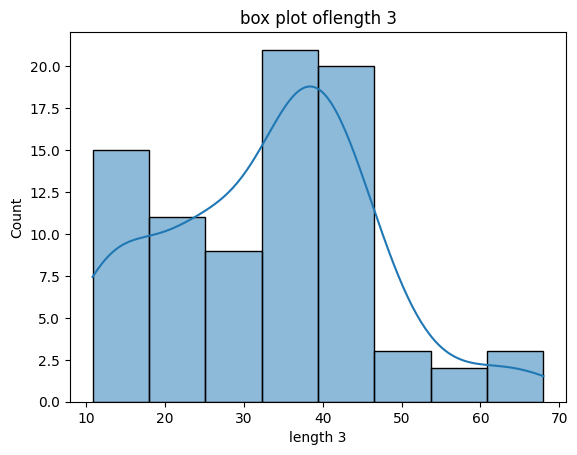

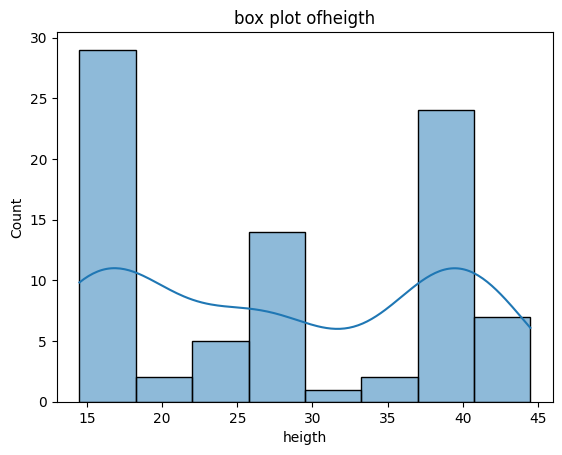

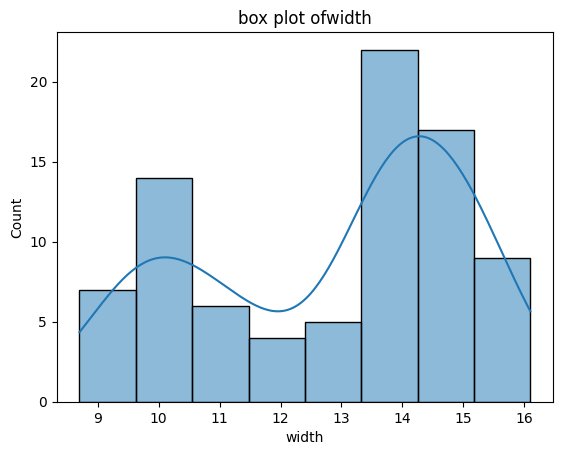

In [ ]:
numerical_cols=df.select_dtypes(include=np.number).columns
numerical_cols
for col in numerical_cols:
    sns.histplot(df[col],kde=True)
    plt.title(f"box plot of{col}")
    plt.show()

In [ ]:
from scipy.stats import skew
skew_values=df[numerical_cols].skew() # showing how much skewed is
print(skew_values)

weight      1.093594
length 1    0.485725
length 2    0.418112
length 3    0.162470
heigth      0.055153
width      -0.494233
dtype: float64


In [ ]:
from scipy.stats.mstats import winsorize
df['weight']=winsorize(df['weight'],limits=(0,0.05))
print("outliers in ' weight column treated using winsorize")
df.head()

outliers in ' weight column treated using winsorize


,species,weight,length 1,length 2,length 3,heigth,width
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2


In [ ]:
data['weight'].max()

1650.0

<Axes: xlabel='weight', ylabel='length 1'>

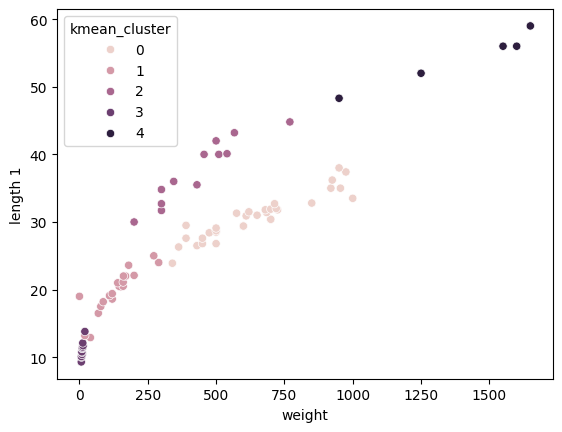

In [ ]:
sns.scatterplot(data,x='weight',y='length 1',hue='kmean_cluster')

In [ ]:
new_fish=np.array([[40,1000,20,30,25,46]])
scaled=scaler.transform(new_fish)
cluster=kmeans.predict(scaled)
cluster

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([4], dtype=int32)

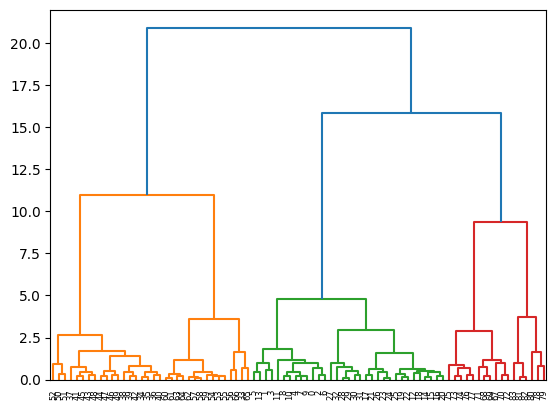

In [ ]:
from scipy.cluster.hierarchy import dendrogram,linkage
mergings=linkage(X_scaled,'ward')  #ward is the method of plot a dendrogram
dendrogram(mergings);

In [ ]:
from scipy.cluster.hierarchy import fcluster
cluster_labels=fcluster(mergings,t=5,criterion='maxclust')
cluster_labels

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5], dtype=int32)

In [ ]:
from sklearn.cluster import AgglomerativeClustering
agg_hc=AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='ward')
agg_cluster=agg_hc.fit_predict(X_scaled)
agg_cluster

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 2, 2, 2, 2, 2])

In [ ]:
data['agg_cluster']=agg_cluster
data.head()

,weight,length 1,length 2,length 3,heigth,width,kmean_cluster,agg_cluster
0,290.0,24.0,26.3,31.2,40.0,13.8,0,0
1,340.0,23.9,26.5,31.1,39.8,15.1,0,0
2,363.0,26.3,29.0,33.5,38.0,13.3,0,0
3,430.0,26.5,29.0,34.0,36.6,15.1,0,0
4,450.0,26.8,29.7,34.7,39.2,14.2,0,0


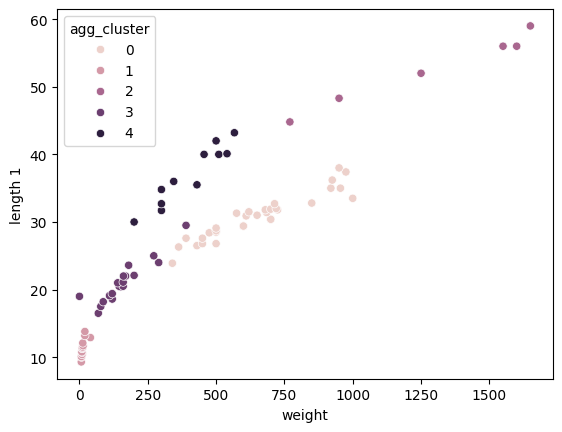

In [ ]:
sns.scatterplot(data,x='weight',y='length 1',hue='agg_cluster');

In [ ]:
sil_scores={}
for i in range(2,11):
  agg_hc=AgglomerativeClustering(n_clusters=i,metric='euclidean',linkage='ward')
  sill_h=silhouette_score(X_scaled,agg_hc.fit_predict(X_scaled))
  sil_scores[i]=sill_h
sil_scores


{2: np.float64(0.4145080144933428),
 3: np.float64(0.511730107492879),
 4: np.float64(0.5465520404406123),
 5: np.float64(0.580437586628707),
 6: np.float64(0.49769191018862036),
 7: np.float64(0.490192410339021),
 8: np.float64(0.4665934938924753),
 9: np.float64(0.4644330100024386),
 10: np.float64(0.4541055703695885)}

In [ ]:
from sklearn.cluster import DBSCAN
db_scan=DBSCAN(eps=0.3,min_samples=5)
db_cluster=db_scan.fit_predict(X_scaled)
db_cluster

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  0,  0,  0,
       -1, -1,  0, -1, -1,  0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1,  1,  1,  1, -1,  1,  1,  1, -1, -1,  1,  1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [ ]:
data['db_cluster']=db_cluster
data.head()

,weight,length 1,length 2,length 3,heigth,width,kmean_cluster,agg_cluster,db_cluster
0,290.0,24.0,26.3,31.2,40.0,13.8,0,0,-1
1,340.0,23.9,26.5,31.1,39.8,15.1,0,0,-1
2,363.0,26.3,29.0,33.5,38.0,13.3,0,0,-1
3,430.0,26.5,29.0,34.0,36.6,15.1,0,0,-1
4,450.0,26.8,29.7,34.7,39.2,14.2,0,0,-1


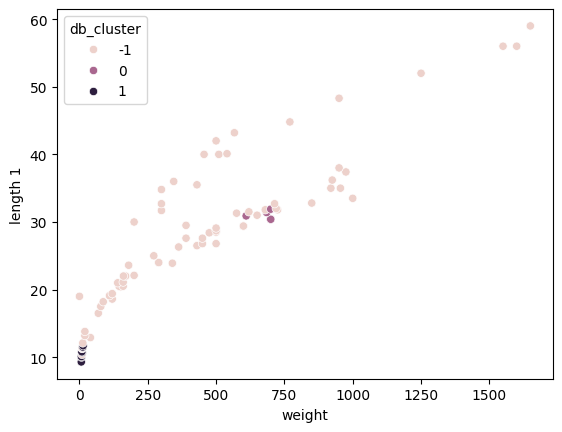

In [ ]:
sns.scatterplot(data,x='weight',y='length 1',hue='db_cluster');

In [ ]:
sil_scores={}
for i in range(2,11):
  db_hc=DBSCAN(metric='euclidean')
  db_cluster=db_hc.fit_predict(X_scaled,db_hc.fit_predict(X_scaled))
  sil_score=silhouette_score(X_scaled,db_cluster)
  sil_scores[i]=sil_score
sil_scores


{2: np.float64(0.2928990591178215),
 3: np.float64(0.2928990591178215),
 4: np.float64(0.2928990591178215),
 5: np.float64(0.2928990591178215),
 6: np.float64(0.2928990591178215),
 7: np.float64(0.2928990591178215),
 8: np.float64(0.2928990591178215),
 9: np.float64(0.2928990591178215),
 10: np.float64(0.2928990591178215)}